# Session 5 — Hyperparameter Tuning

**Goal:** understand what tuning is by visualizing how `max_depth` affects a Decision Tree.

- Low depth → underfitting (too simple)
- High depth → overfitting (memorizes training data)
- Sweet spot → best generalization on unseen data

In [1]:
!pip install matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
df = pd.read_csv('titanic.csv')

X = df[['Age', 'SibSp', 'Parch', 'Fare', 'Pclass', 'Sex', 'Embarked']]
y = df['Survived']

num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (712, 7)
Test size: (179, 7)


In [3]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

## Visualizing Overfitting vs Underfitting

For each `max_depth` value we record:
- **Train accuracy** — how well the model fits training data
- **Test accuracy** — how well it generalizes to unseen data

The gap between them tells you if the model is overfitting.

In [4]:
depths = range(1, 20)
train_scores = []
test_scores = []
cv_scores = []

for depth in depths:
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])

    # train accuracy
    pipe.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, pipe.predict(X_train)))

    # test accuracy
    test_scores.append(accuracy_score(y_test, pipe.predict(X_test)))

    # cross-val accuracy (most reliable)
    cv = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())

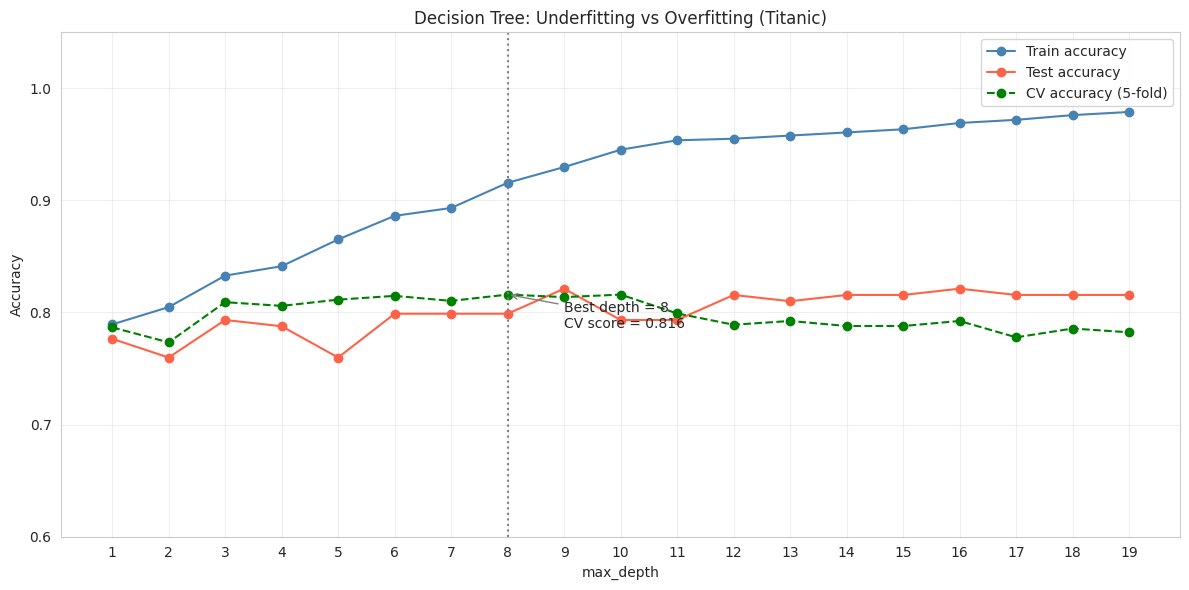

Best max_depth by CV: 8
Best CV accuracy:     0.8160


In [5]:
plt.figure(figsize=(12, 6))

plt.plot(depths, train_scores, marker='o', label='Train accuracy', color='steelblue')
plt.plot(depths, test_scores,  marker='o', label='Test accuracy',  color='tomato')
plt.plot(depths, cv_scores,    marker='o', label='CV accuracy (5-fold)', color='green', linestyle='--')

best_depth = depths[np.argmax(cv_scores)]
best_score = max(cv_scores)
plt.axvline(x=best_depth, color='gray', linestyle=':', linewidth=1.5)
plt.annotate(
    f'Best depth = {best_depth}\nCV score = {best_score:.3f}',
    xy=(best_depth, best_score),
    xytext=(best_depth + 1, best_score - 0.03),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='gray')
)

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Underfitting vs Overfitting (Titanic)')
plt.legend()
plt.xticks(list(depths))
plt.ylim(0.6, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best max_depth by CV: {best_depth}')
print(f'Best CV accuracy:     {best_score:.4f}')

## How to read this plot

| What you see | What it means |
|---|---|
| Train accuracy rises, test stays low | **Overfitting** — tree memorizes, doesn't generalize |
| Both train and test are low | **Underfitting** — tree too shallow, misses patterns |
| Train ≈ Test, both high | **Sweet spot** — good generalization |
| Large gap between train and test | Model complexity too high |

In [6]:
# Now use GridSearchCV to tune all parameters at once
pipe = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'model__max_depth':        [2, 3, 4, 5, 6, 7, 8, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf':  [1, 2, 4, 8],
    'model__criterion':         ['gini', 'entropy']
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X, y)

print('Best params:', grid.best_params_)
print('Best CV accuracy:', grid.best_score_)

Best params: {'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 20}
Best CV accuracy: 0.827185989580064
